# Increase Fairness in Your Machine Learning Project with Disparate Impact Analysis using Pandas, Numpy, H2O, and Datatable

#### Assess if your machine learning model is treating different groups of people similarly or differently

Fairness in machine learning is a very important topic in many respects, but it is a highly complex entity. So much so that leading researchers in the field have yet to agree on a strict definition (there is no concrete "fairness metric"). However, there is a practical way to discuss and handle *observational* fairness or simply put, how your model predictions affect different groups. This procedure is known as disparate impact analysis (DIA). DIA is far from perfect, as it relies heavily on user-defined thresholds and reference levels for disparity and does not attempt to remediate disparity or provide information on sources of disparity, but it is a fairly straightforward method to quantify your model’s behavior across sensitive demographic segments or other potentially interesting groups of observations. DIA is also an accepted, regulation-compliant tool for fair-lending purposes in the U.S. financial services industry. 

This example DIA notebook starts by training a gradient boosting machine (GBM) regression model on the UCI credit card data using the popular open source library, `h2o`. Several metrics are calculated to describe the distribution of the models predictions. A basic DIA procedure is then conducted using the calculated metrics.

For an excellent and free reference on the topics of fairness and machine learning be sure to follow the book being written by Solon Barocas, Moritz Hardt and Arvind Narayanan: https://fairmlbook.org/. 

For Python fairness libraries that go far beyond the scope of this notebook see: 
* aequitas: https://github.com/dssg/aequitas
* AI Fairness 360: http://aif360.mybluemix.net/
* Themis: https://github.com/LASER-UMASS/Themis

#### Python imports
In general, NumPy and Pandas will be used for data manipulation purposes and h2o will be used for modeling tasks. 

In [1]:
import hmli                                        
from hmli.estimators.gbm import H2OGradientBoostingEstimator       

import numpy as np   
import pandas as pd 
import datatable as dt
from datatable import f
from mli.fairness.disparate_impact_analysis import RegressionDisparateImpactAnalysis
%matplotlib inline     

#### Start `h2o`
H2O is both a library and a server. The machine learning algorithms in the library take advantage of the multithreaded and distributed architecture provided by the server to train machine learning algorithms extremely efficiently. The API for the library was imported above in cell 1, but the server still needs to be started.

In [2]:
h2o.init(max_mem_size='2G')       
h2o.remove_all()                  

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: java version "1.8.0_101"; Java(TM) SE Runtime Environment (build 1.8.0_101-b13); Java HotSpot(TM) 64-Bit Server VM (build 25.101-b13, mixed mode)
  Starting server from /Users/user/Desktop/mli-2/mli2_env/lib/python3.6/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/55/rj4cny_s29q4vn1wjt_x08sm0000gn/T/tmpga101dsm
  JVM stdout: /var/folders/55/rj4cny_s29q4vn1wjt_x08sm0000gn/T/tmpga101dsm/h2o_user_started_from_python.out
  JVM stderr: /var/folders/55/rj4cny_s29q4vn1wjt_x08sm0000gn/T/tmpga101dsm/h2o_user_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321... successful.


H2O cluster uptime:,01 secs
H2O cluster timezone:,America/Los_Angeles
H2O data parsing timezone:,UTC
H2O cluster version:,3.22.0.2
H2O cluster version age:,6 months and 19 days !!!
H2O cluster name:,H2O_from_python_user_c388bn
H2O cluster total nodes:,1
H2O cluster free memory:,1.778 Gb
H2O cluster total cores:,8
H2O cluster allowed cores:,8
H2O cluster status:,"accepting new members, healthy"


## 1. Download, explore, and prepare UCI credit card data

UCI credit card data: https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

The UCI credit card data contains demographic and payment information about credit card customers in Taiwan in the year 2005. The data set contains 22 input variables: 

* **`SEX`**: 1 = male; 2 = female
* **`EDUCATION`**: 1 = graduate school; 2 = university; 3 = high school; 4 = others 
* **`MARRIAGE`**: 1 = married; 2 = single; 3 = others
* **`AGE`**: Age in years 
* **`PAY_0`, `PAY_2` - `PAY_6`**: History of past payment; `PAY_0` = the repayment status in September, 2005; `PAY_2` = the repayment status in August, 2005; ...; `PAY_6` = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; ...; 8 = payment delay for eight months; 9 = payment delay for nine months and above. 
* **`BILL_AMT1` - `BILL_AMT6`**: Amount of bill statement (NT dollar). `BILL_AMNT1` = amount of bill statement in September, 2005; `BILL_AMT2` = amount of bill statement in August, 2005; ...; `BILL_AMT6` = amount of bill statement in April, 2005. 
* **`PAY_AMT1` - `PAY_AMT6`**: Amount of previous payment (NT dollar). `PAY_AMT1` = amount paid in September, 2005; `PAY_AMT2` = amount paid in August, 2005; ...; `PAY_AMT6` = amount paid in April, 2005. 

These 22 input variables are used to predict the target variable, `LIMIT_BAL` (amount of given credit (NT dollar)).

Because h2o accepts both numeric and character inputs, some variables will be recoded into more transparent character values.

#### Import data and clean
The credit card data is available as an `.xls` file.

In [3]:
# import XLS file
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'
data = pd.read_excel(url, skiprows=1)

In [4]:
# See first 5 rows of dataset
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


#### Assign modeling roles
The shorthand name `y` is assigned to the prediction target. `X` is assigned to all other input variables in the credit card data except the row indentifier, `ID`.

In [5]:
# Assign target and inputs for GBM
y = 'LIMIT_BAL'
X = [name for name in data.columns if name not in [y, 'ID', 'default payment next month']]
print('y =', y)
print('X =', X)

y = LIMIT_BAL
X = ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


#### Helper function for recoding values in the UCI credict card data
This simple function maps longer, more understandable character string values from the UCI credit card data dictionary to the original integer values of the input variables found in the dataset. These character values can be used directly in h2o decision tree models, and the function returns the original Pandas DataFrame as an h2o object, an H2OFrame. H2o models cannot run on Pandas DataFrames. They require H2OFrames.

In [6]:
def recode_cc_data(frame):
    
    """ Recodes numeric categorical variables into categorical character variables
    with more transparent values. 
    
    Args:
        frame: Pandas DataFrame version of UCI credit card data.
        
    Returns: 
        H2OFrame with recoded values.
        
    """
    
    # Define recoded values
    sex_dict = {1:'male', 2:'female'}
    education_dict = {0:'other', 1:'graduate school', 2:'university', 3:'high school', 
                      4:'other', 5:'other', 6:'other'}
    marriage_dict = {0:'other', 1:'married', 2:'single', 3:'divorced'}
    pay_dict = {-2:'no consumption', -1:'pay duly', 0:'use of revolving credit', 1:'1 month delay', 
                2:'2 month delay', 3:'3 month delay', 4:'4 month delay', 5:'5 month delay', 6:'6 month delay', 
                7:'7 month delay', 8:'8 month delay', 9:'9+ month delay'}
    
    # Recode values using Pandas apply() and anonymous function
    frame['SEX'] = frame['SEX'].apply(lambda i: sex_dict[i])
    frame['EDUCATION'] = frame['EDUCATION'].apply(lambda i: education_dict[i])    
    frame['MARRIAGE'] = frame['MARRIAGE'].apply(lambda i: marriage_dict[i]) 
    for name in frame.columns:
        if name in ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
            frame[name] = frame[name].apply(lambda i: pay_dict[i])            
                
    return h2o.H2OFrame(frame)

data = recode_cc_data(data)

Parse progress: |█████████████████████████████████████████████████████████| 100%


#### Display descriptive statistics
The h2o `describe()` function displays a brief description of the credit card data. For the categorical input variables `SEX`, `EDUCATION`, `MARRIAGE`, and `PAY_0`-`PAY_6`, the new character values created above in cell 5 are visible. Basic descriptive statistics are displayed for numeric inputs.

In [7]:
data[X + [y]].describe()

Rows:30000
Cols:23




,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,LIMIT_BAL
type,enum,enum,enum,int,enum,enum,enum,enum,enum,enum,int,int,int,int,int,int,int,int,int,int,int,int,int
mins,,,,21.0,,,,,,,-165580.0,-69777.0,-157264.0,-170000.0,-81334.0,-339603.0,0.0,0.0,0.0,0.0,0.0,0.0,10000.0
mean,,,,35.48549999999994,,,,,,,51223.33090000009,49179.07516666668,47013.15479999971,43262.9489666666,40311.40096666653,38871.76039999991,5663.580500000014,5921.16350000001,5225.681500000005,4826.076866666661,4799.387633333302,5215.502566666664,167484.32266666688
maxs,,,,79.0,,,,,,,964511.0,983931.0,1664089.0,891586.0,927171.0,961664.0,873552.0,1684259.0,896040.0,621000.0,426529.0,528666.0,1000000.0
sigma,,,,9.21790406809016,,,,,,,73635.86057552959,71173.76878252836,69349.38742703681,64332.85613391641,60797.1557702648,59554.10753674574,16563.280354025763,23040.870402057226,17606.961469803115,15666.159744031993,15278.305679144793,17777.465775435332,129747.66156720225
zeros,,,,0,,,,,,,2008,2506,2870,3195,3506,4020,5249,5396,5968,6408,6703,7173,0
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
0,female,university,married,24.0,2 month delay,2 month delay,pay duly,pay duly,no consumption,no consumption,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,20000.0
1,female,university,single,26.0,pay duly,2 month delay,use of revolving credit,use of revolving credit,use of revolving credit,2 month delay,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,120000.0
2,female,university,single,34.0,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,90000.0


## 2. Train an H2O GBM regression model

#### Split data into training and test sets for early stopping
The credit card data is split into training and test sets to monitor and prevent overtraining. Reproducibility is also an important factor in creating trustworthy models, and randomly splitting datasets can introduce randomness in model predictions and other results. A random seed is used here to ensure the data split is reproducible.

In [8]:
# Split into training and validation
train, test = data.split_frame([0.7], seed=12345)

# Summarize split
print('Train data rows = %d, columns = %d' % (train.shape[0], train.shape[1]))
print('Test data rows = %d, columns = %d' % (test.shape[0], test.shape[1]))

Train data rows = 21060, columns = 25
Test data rows = 8940, columns = 25


#### Train h2o GBM regression model
Many tuning parameters must be specified to train a GBM using h2o. Typically a grid search would be performed to identify the best parameters for a given modeling task using the `H2OGridSearch` class. For brevity's sake, a previously-discovered set of good tuning parameters are specified here. Because gradient boosting methods typically resample training data, an additional random seed is also specified for the h2o GBM using the `seed` parameter to create reproducible predictions, error rates, and variable importance values. To avoid overfitting, the `stopping_rounds` parameter is used to stop the training process after the test error fails to decrease for 5 iterations. 

In [9]:
# Initialize GBM model
model = H2OGradientBoostingEstimator(ntrees=150,            # maximum 150 trees in GBM
                                     max_depth=4,           # trees can have maximum depth of 4
                                     sample_rate=0.9,       # use 90% of rows in each iteration (tree)
                                     col_sample_rate=0.9,   # use 90% of variables in each iteration (tree)
                                     stopping_rounds=5,     # stop if validation error does not decrease for 5 iterations (trees)
                                     score_tree_interval=1, # for reproducibility, set higher for bigger data
                                     model_id='dia_gbm',    # for locating the model in Flow UI 
                                     seed=12345)            # for reproducibility

# Train a GBM model
model.train(y=y, x=X, training_frame=train, validation_frame=test)

# Print AUC
print('GBM Test RMSE = %.2f' % model.rmse(valid=True))

# Uncomment to see model details
# print(model) 

gbm Model Build progress: |███████████████████████████████████████████████| 100%
GBM Test RMSE = 94201.35


#### Display variable importance
During training, the h2o GBM aggregates the improvement in error caused by each split in each decision tree across all the decision trees in the ensemble. These values are attributed to the input variable used in each split and give an indication of the contribution each input variable makes toward the model's predictions. The variable importance ranking should be parsimonious with human domain knowledge and reasonable expectations.

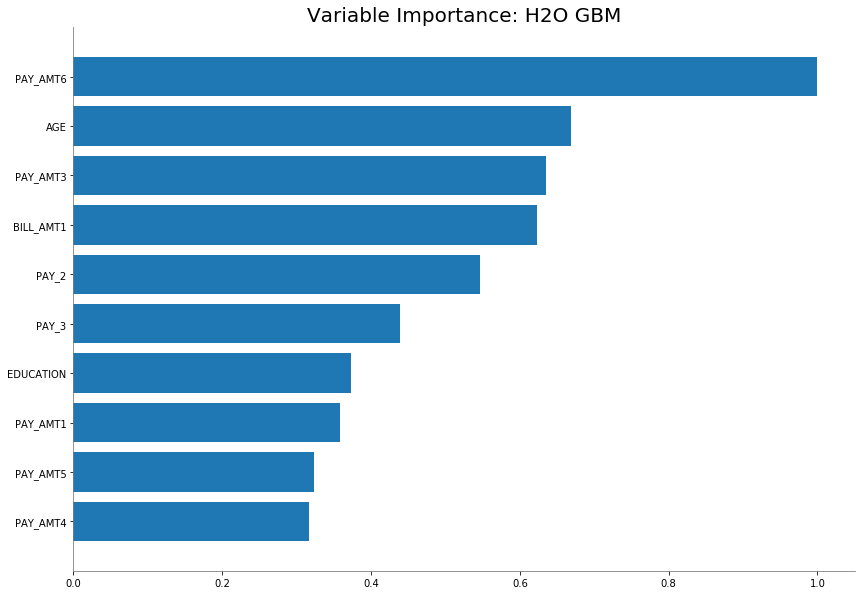

In [10]:
model.varimp_plot()

In sections below this notebook will assess whether the GBM is making disparate predictions for customers across educational levels. For now, it's a somewhat heartening sign that the GBM is not placing high importance on the `EDUCATION` variable.

#### Bind model predictions to test data for further calculations

In [11]:
# Cbind predictions to training frame
# give them a nice name
yhat = 'p_LIMIT_BAL'
preds1 = test['ID'].cbind(model.predict(test))
preds1.columns = ['ID', yhat]
test_yhat = test.cbind(preds1[yhat]).as_data_frame()
test_yhat.head()

gbm prediction progress: |████████████████████████████████████████████████| 100%


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,p_LIMIT_BAL
0,4,50000,female,university,married,37,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,...,28959,29547,2000,2019,1200,1100,1069,1000,0,68468.310763
1,8,100000,female,university,single,23,use of revolving credit,pay duly,pay duly,use of revolving credit,...,-159,567,380,601,0,581,1687,1542,0,58186.355892
2,10,20000,male,high school,single,35,no consumption,no consumption,no consumption,no consumption,...,13007,13912,0,0,0,13007,1122,0,0,203420.783278
3,16,50000,female,high school,divorced,23,1 month delay,2 month delay,use of revolving credit,use of revolving credit,...,29531,30211,0,1500,1100,1200,1300,1100,0,14834.551859
4,17,20000,male,graduate school,single,24,use of revolving credit,use of revolving credit,2 month delay,2 month delay,...,17905,19104,3200,0,1500,0,1650,0,1,25990.472367


#### Create datatable version of test_yhat

In [12]:
test_yhat_dt = dt.Frame(test_yhat)
test_yhat_dt.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,…,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month,p_LIMIT_BAL
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,▪▪▪▪,,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,4,50000,female,university,married,37,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,…,1100,1069,1000,0,68468.3
1,8,100000,female,university,single,23,use of revolving credit,pay duly,pay duly,use of revolving credit,…,581,1687,1542,0,58186.4
2,10,20000,male,high school,single,35,no consumption,no consumption,no consumption,no consumption,…,13007,1122,0,0,203421
3,16,50000,female,high school,divorced,23,1 month delay,2 month delay,use of revolving credit,use of revolving credit,…,1200,1300,1100,0,14834.6
4,17,20000,male,graduate school,single,24,use of revolving credit,use of revolving credit,2 month delay,2 month delay,…,0,1650,0,1,25990.5
5,19,360000,female,graduate school,married,49,1 month delay,no consumption,no consumption,no consumption,…,0,0,0,0,238411
6,22,120000,female,university,married,39,pay duly,pay duly,pay duly,pay duly,…,632,316,0,1,176158
7,30,50000,male,graduate school,single,26,use of revolving credit,use of revolving credit,use of revolving credit,use of revolving credit,…,1000,1600,0,0,64417.5
8,32,50000,male,university,single,33,2 month delay,use of revolving credit,use of revolving credit,use of revolving credit,…,1000,1000,716,1,57171.8


# 3. Define DIA object

In [13]:
dia = RegressionDisparateImpactAnalysis(actual_column='LIMIT_BAL', predict_column='p_LIMIT_BAL', 
                                        group_column='EDUCATION')

# 4. Disparate Impact Analysis

#### Calculate and report metrics

In [14]:
metrics_frame = dia.get_metrics(test_yhat_dt)
metrics_frame

,Groups,N,Mean Prediction,Std.Dev Prediction,Maximum Prediction,Minimum Prediction,R2,RMSE
,▪▪▪▪,▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,graduate school,3150,213520,84757.1,555145,21106.9,0.407806,103209
1,high school,1466,131803,78947.5,507049,5296.09,0.473463,82623.7
2,other,133,193781,80021.3,538114,36141.5,0.32917,94826.3
3,university,4191,145462,79775.9,566079,−2435.19,0.447129,90827.9


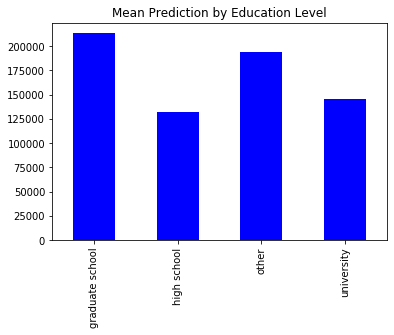

In [15]:
# Convert datatable to Pandas for plotting
metrics_frame_pandas = metrics_frame.to_pandas()
metrics_frame_pandas.index = metrics_frame_pandas["Groups"].values
metrics_frame_pandas.drop("Groups", axis=1, inplace=True)
_ = metrics_frame_pandas['Mean Prediction'].plot(kind='bar', color='b', title='Mean Prediction by Education Level')

In [16]:
disp_frame = dia.get_disparity(frame=test_yhat_dt, ref_level="graduate school", fetch_metrics=True)
disp_frame

ed_levels = dt.unique(test_yhat_dt[:, 'EDUCATION']).to_list()[0]

# Small utility function to format pandas table output
def disparate_red(val):
   
   color = 'blue' if (dia.low_threshold < val < dia.high_threshold) else 'red'
   return 'color: %s' % color 

disp_frame_pd = disp_frame.to_pandas().drop(['Groups'], axis=1)
disp_frame_pd.index = ed_levels
disp_frame_pd.head()
# Display results
disp_frame_pd.style.applymap(disparate_red)

,N,Mean Prediction Disparity,Std.Dev Prediction Disparity,Maximum Prediction Disparity,Minimum Prediction Disparity,R2 Disparity,RMSE Disparity
graduate school,3150,1,1,1,1,1,1
high school,1466,0.617288,0.931456,0.913363,0.250918,1.161,0.800545
other,133,0.907555,0.944125,0.969321,1.71231,0.807174,0.918777
university,4191,0.681256,0.941229,1.0197,-0.115374,1.09643,0.880036


#### Plot mean prediction disparity

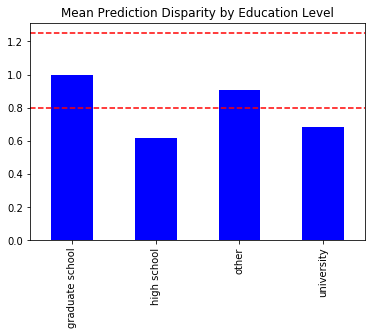

In [17]:
ax = disp_frame_pd['Mean Prediction Disparity'].plot(kind='bar', color='b', title='Mean Prediction Disparity by Education Level')
_ = ax.axhline(dia.low_threshold, color='r', linestyle='--')
_ = ax.axhline(dia.high_threshold, color='r', linestyle='--')

In [18]:
par_frame = dia.get_parity(frame=test_yhat_dt, ref_level="graduate school", get_disparity=True)
par_frame

# Small utility function to format pandas table output    
def color_false_red(val):

    color = 'red' if not val else 'blue'
    return 'color: %s' % color 

par_frame_pd = par_frame.to_pandas()
par_frame_pd = par_frame_pd.drop(["Groups"], axis=1)
par_frame_pd.index = ed_levels + ["all"]
# Display results
par_frame_pd.style.applymap(color_false_red)

,N,Mean Prediction Parity,Std.Dev Prediction Parity,Maximum Prediction Parity,Minimum Prediction Parity,R2 Parity,RMSE Parity,Overall Fairness
graduate school,3150,1,1,1,1,1,1,1
high school,1466,0,1,1,0,1,1,0
other,133,1,1,1,0,1,1,0
university,4191,0,1,1,0,1,1,0
all,0,0,1,1,0,1,1,0


#### Shutdown H2O
After using h2o, it's typically best to shut it down. However, before doing so, users should ensure that they have saved any h2o data structures, such as models and H2OFrames, or scoring artifacts, such as POJOs and MOJOs.

In [19]:
# Be careful, this can erase your work!
h2o.cluster().shutdown(prompt=False)

H2O session _sid_9bc1 closed.


#### Conclusion

This notebook outlines a basic approach to DIA. In a complex, real-world machine learning project the hard-to-define phenomenas of sociological bias and unfairness can materialize in many ways and from many different sources. Although far from a flawless technique, the beauty of DIA is it is straightforward to implement, functions in a model-agnostic fashion on known labels and model predictions, and is applied in complex real-world fair lending situations, so it can probably be applied to your model too!

Why risk being called out in the media for training an unfair model? Or why not investigate the monetary opportunity costs of type I errors and potential losses from type II errors? Why not do the right thing and investigate how your model treats people?